# Read data

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:

arr = np.load("EMI_2026-02-03_18-00-38-109/CH4_raw.npy")
arr.shape

(50, 10000)

In [3]:
arr

array([[-3072, -3200, -3584, ..., -2816, -2304, -2560],
       [-2048, -2432, -2816, ..., -2560, -1920, -2048],
       [-3200, -3200, -2944, ..., -2816, -3456, -3072],
       ...,
       [-2944, -2688, -2688, ..., -1664, -2176, -2176],
       [-3072, -1280, -2560, ..., -1536, -1792, -3200],
       [-3456, -2944, -3072, ..., -2176, -2048, -2688]],
      shape=(50, 10000), dtype=int16)

In [4]:
arr.flatten() 

array([-3072, -3200, -3584, ..., -2176, -2048, -2688],
      shape=(500000,), dtype=int16)

In [5]:
yraw=arr.flatten() 

In [6]:
with open("EMI_2026-02-03_18-00-38-109/CH4_seeting.txt") as f:
    dic=f.read()

import ast
# Convert string to dict
dic = ast.literal_eval(dic)
dic

{'BANDWIDTH': 'FULL\n',
 'COUPLING': 'DC\n',
 'IMPEDANCE': 'FIFTY\n',
 'INVERT': '0\n',
 'OFFSET': '0.0E0\n',
 'POSITION': '-4.0E-2\n',
 'PROBe': '1.0E1\n',
 'SCALE': '1.0E1\n',
 'channel': 'CH4',
 'x_increment': '2.0E-8\n',
 'x_origin': '-1.002E-4\n',
 'y_increment': '1.5625E-3\n',
 'y_offset': '-2.56E2\n',
 'y_origin': '0.0E0\n'}

In [7]:
def raw_to_volte(raw, dic):
    y_increment =  float(dic["y_increment"])
    y_origin =  float(dic["y_origin"])
    y_offset =  float(dic["y_offset"])
    voltage = (raw - y_offset) * y_increment + y_origin
    return voltage 



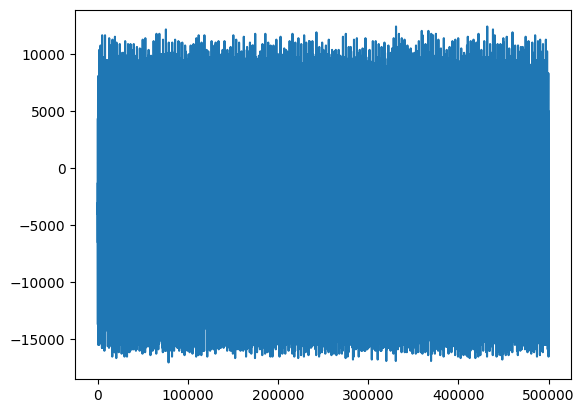

In [8]:
plt.plot(yraw)

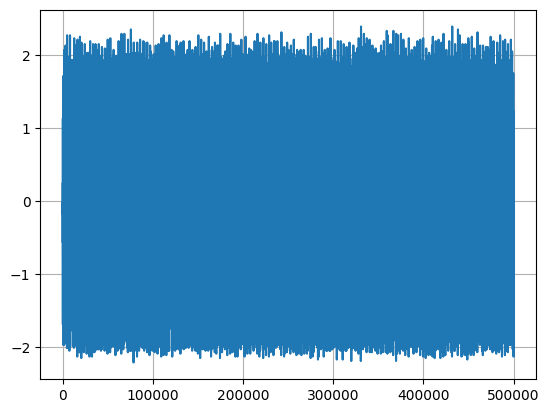

In [9]:
y=raw_to_volte(yraw, dic)
y=y-y.mean()
y=y/float(dic['SCALE'])

plt.plot(y)
plt.grid()

In [10]:
rms=np.sqrt((y**2).mean())
rms, "vrms"

(np.float64(0.21168495266260567), 'vrms')

In [11]:
Ts=float(dic['x_increment'])
1e-6/Ts,"Mhz"

(50.0, 'Mhz')

# FINAL EMI EMULATOR 

Summary of the algorithm from raw signal to final detector results:

1.  **RBW Design:** Calculates the specific time-length of a **Gaussian Window** to physically guarantee a 9 kHz Resolution Bandwidth (CISPR requirement).
2.  **Step Calibration:** Determines the necessary FFT size (adding zero-padding) to ensure the output points are spaced exactly every **2.5 kHz**.
3.  **Segmentation (STFT):** Slices the long signal into thousands of small, **90% overlapping** frames to capture transient pulses without loss.
4.  **Spectral Matrix:** Applies the window and performs FFT on every frame, creating a 2D matrix of **Voltage vs. Time** for every frequency.
5.  **Envelope Detection:** Converts the complex FFT output into absolute voltage magnitude (multiplying by 2 to correct for one-sided spectrum).
6.  **Peak Detector:** Iterates through every frequency bin and finds the **maximum** value occurring over time.
7.  **Average Detector:** Iterates through every frequency bin and calculates the **arithmetic mean** of the voltage over time.
8.  **Quasi-Peak Detector:** Passes the time-envelope of every frequency through a **digital IIR filter** that mimics the charge/discharge physics of a capacitor ($ \tau_{charge}=1ms $, $ \tau_{discharge}=160ms $).
9.  **Output:** Converts the final arrays from Volts to **dBµV**.

In [12]:
import numpy as np
import scipy.signal
import scipy.fft
from numba import jit
import matplotlib.pyplot as plt

# =========================================================
# 1. Numba Accelerators (Fast Detectors)
# =========================================================
@jit(nopython=True)
def quasi_peak_filter(magnitude_signal, dt, tau_charge, tau_discharge):
    """
    Simulates the CISPR Quasi-Peak detector circuit (RC charge/discharge).
    """
    n_samples = len(magnitude_signal)
    output = np.zeros(n_samples, dtype=np.float64)
    
    # Pre-calculate exponential coefficients
    alpha_charge = 1.0 - np.exp(-dt / tau_charge)
    alpha_discharge = 1.0 - np.exp(-dt / tau_discharge)
    
    current_val = 0.0
    
    for i in range(n_samples):
        in_val = magnitude_signal[i]
        
        # Analog circuit emulation
        if in_val > current_val:
            current_val += alpha_charge * (in_val - current_val)
        else:
            current_val -= alpha_discharge * current_val
            
        output[i] = current_val
        
    return np.max(output)

@jit(nopython=True, parallel=True)
def run_detectors_parallel(spectrogram_mag, dt, tau_c, tau_d):
    """
    Parallel loop over all frequency bins to compute Peak, Avg, and QP.
    """
    n_time, n_freq = spectrogram_mag.shape
    
    res_peak = np.zeros(n_freq)
    res_avg = np.zeros(n_freq)
    res_qp = np.zeros(n_freq)
    
    for f in range(n_freq):
        time_trace = spectrogram_mag[:, f]
        
        # 1. Peak
        res_peak[f] = np.max(time_trace)
        
        # 2. Average
        res_avg[f] = np.mean(time_trace)
        
        # 3. Quasi-Peak
        res_qp[f] = quasi_peak_filter(time_trace, dt, tau_c, tau_d)
        
    return res_peak, res_avg, res_qp

# =========================================================
# 2. Main EMI Receiver Function
# =========================================================
def emi_receiver_fft(signal, fs, rbw=9000, step=2500, band='B'):
    """
    FFT-based EMI Receiver Emulation.
    
    Parameters:
    -----------
    signal : array_like
        Input signal (Volts)
    fs : float
        Sampling Frequency (Hz)
    rbw : float
        Resolution Bandwidth (Hz). Default 9 kHz.
    step : float
        Frequency Step size (Hz). Default 2500 Hz (2.5 kHz).
        The code will use Zero-Padding interpolation to achieve this exact step.
    band : str
        CISPR Band ('A' or 'B'). 'B' is 150kHz-30MHz.
        
    Returns:
    --------
    freqs, peak_dBuV, avg_dBuV, qp_dBuV
    """
    
    # --- A. Setup Constants ---
    if band == 'A': 
        tau_c, tau_d = 45e-3, 500e-3
    elif band == 'B': 
        tau_c, tau_d = 1e-3, 160e-3
    else: 
        tau_c, tau_d = 1e-3, 550e-3

    # --- B. Design the "RBW" Window ---
    # We need a Gaussian window where the 6dB bandwidth equals RBW.
    sigma_f = rbw / (2 * np.sqrt(2 * np.log(2)))
    sigma_t = 1.0 / (2 * np.pi * sigma_f)
    
    # Window length (Physical Filter Width)
    win_len_sec = 6 * sigma_t 
    nperseg = int(win_len_sec * fs)
    if nperseg % 2 == 0: nperseg += 1
    
    # --- C. Configure FFT Step Size ---
    # Formula: Step = Fs / Nfft
    # Therefore: Nfft = Fs / Step
    target_nfft = int(round(fs / step))
    
    # Validation: Nfft cannot be smaller than the window length
    if target_nfft < nperseg:
        print(f"Warning: Step {step}Hz is too large for RBW {rbw}Hz.")
        print(f"         Forcing natural resolution: {fs/nperseg:.2f} Hz")
        nfft = nperseg
    else:
        nfft = target_nfft

    # Generate Gaussian Window
    sigma_samples = sigma_t * fs
    window = scipy.signal.windows.gaussian(nperseg, std=sigma_samples)
    
    # Normalize Window Energy (Sum=1 ensures correct amplitude after FFT)
    window = window / np.sum(window) 
    
    # --- D. Overlap Configuration ---
    # 90% Overlap is standard for FFT-Scan to capture transient peaks
    overlap_ratio = 0.90 
    noverlap = int(nperseg * overlap_ratio)
    step_size = nperseg - noverlap
    
    # Detector Timing
    fs_detector = fs / step_size
    dt_detector = 1.0 / fs_detector
    
    # Debug Info
    actual_step = fs / nfft
    print(f"--------------------------------------------------")
    print(f"EMI Receiver Configuration:")
    print(f"  RBW           : {rbw} Hz")
    print(f"  Step Size     : {actual_step:.2f} Hz (Target: {step} Hz)")
    print(f"  Window Size   : {nperseg} samples")
    print(f"  FFT Size      : {nfft} samples (Zero-Padding: {nfft > nperseg})")
    print(f"  Detector Time : {dt_detector*1e3:.3f} ms")
    print(f"--------------------------------------------------")

    if dt_detector > tau_c:
        print("WARNING: Sample rate/Overlap too low for accurate QP detection!")

    # --- E. Perform STFT ---
    # padded=True allows signal to be handled at boundaries
    f_axis, t_axis, Zxx = scipy.signal.stft(
        signal, fs, 
        window=window, 
        nperseg=nperseg,    # Controls RBW Physics
        noverlap=noverlap, 
        nfft=nfft,          # Controls Frequency Step (Display)
        boundary='zeros',
        padded=True
    )

    # Convert to One-Sided Voltage Magnitude
    # Multiply by 2.0 to account for negative frequency energy
    mag_spectrogram = np.abs(Zxx) * 2.0
    mag_spectrogram_T = mag_spectrogram.T 

    # --- F. Run Detectors ---
    peak_v, avg_v, qp_v = run_detectors_parallel(mag_spectrogram_T, dt_detector, tau_c, tau_d)

    # --- G. Convert to dBµV ---
    def to_dbuv(v_array):
        # 1e-12 prevents log(0)
        return 20 * np.log10(np.maximum(v_array, 1e-12) * 1e6)

    return f_axis, to_dbuv(peak_v), to_dbuv(avg_v), to_dbuv(qp_v)

# =========================================================
# 3. Verification Script
# =========================================================
if False : # __name__ == "__main__":
    # Settings
    Fs = 100e6         # 100 MS/s
    Duration = 0.05    # 50ms capture
    t = np.arange(int(Fs * Duration)) / Fs
    
    # Create a test signal (Sine wave + Pulse)
    sig = 100e-6 * np.sin(2 * np.pi * 150e3 * t) 
    
    # Call the function with default step=2500
    print("Processing...")
    freqs, peak, avg, qp = emi_receiver_fft(sig, Fs, rbw=9000, step=2500, band='B')
    
    # Verify the output steps
    print("\nVerification of First 10 Frequency Steps:")
    print(freqs[:10])
    
    # Plot
    plt.figure(figsize=(10, 5))
    mask = freqs <= 1e6 # Zoom to 1MHz
    plt.plot(freqs[mask]/1e3, peak[mask], label='Peak')
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Amplitude (dBµV)')
    plt.title(f'EMI Receiver Spectrum (Step = {freqs[1]-freqs[0]:.1f} Hz)')
    plt.legend()
    plt.grid(True)
    plt.show()

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


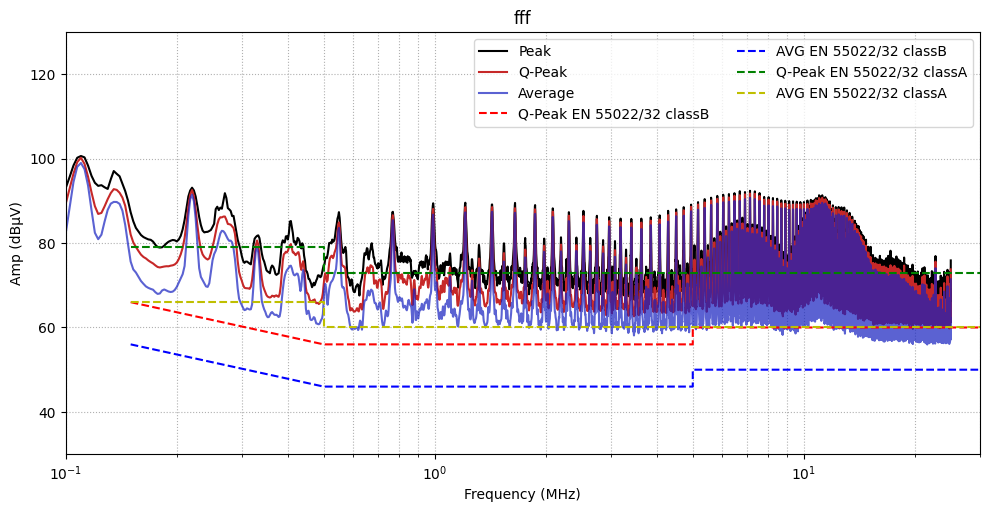

In [13]:
freqs, peak, avg, qp = emi_receiver_fft(y,1/Ts, rbw=9000, band='B')

title="fff"
plt.figure(figsize=(10,5))
plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red
plt.semilogx(freqs*1e-6, qp, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")







plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [14]:

ts=1e-8
tf=(1.2e-2+ts)*4
(tf/ts)/(1e4*50), 1e-6/ts, "MHz"

(9.600008, 100.0, 'MHz')

In [15]:
f_fix=140e3
int(0.5*(1/f_fix) /ts)

357

In [16]:
v=True 
arr=[]
for i in range(int(tf/ts)):
    arr.append(v)
    if i%int(0.5*(1/f_fix) /ts)==0:
        v=not v


In [17]:
time = np.arange(0,tf,ts)

In [19]:
#freqsw = np.interp(x=time, xp=tsweep, fp=freq)

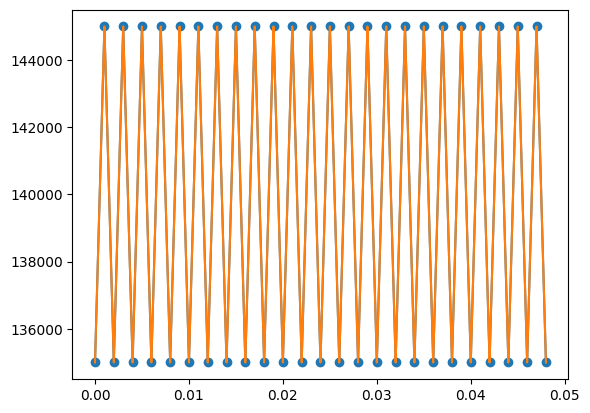

In [20]:
sweep=1e-3
tsweep = np.arange(0,tf,sweep)
freq=np.array([i%2 for i in range(len(tsweep))])
freq=freq*10e3+135e3
freqsw = np.interp(x=time, xp=tsweep, fp=freq)
plt.plot( tsweep ,freq, marker = "o" )
plt.plot( time ,freqsw )

# TRY 1

In [21]:
v=True 
arr2=[]
for i in range(int(tf/ts)):
    arr2.append(v)
    if i%int(0.5*(1/freqsw[i]) /ts)==0:
        v=not v


In [22]:
int(tf/ts)

4800004

In [23]:
import numpy as np

In [24]:
sig= np.array(arr)*0.02-0.01
sig2= np.array(arr2)*0.02-0.01

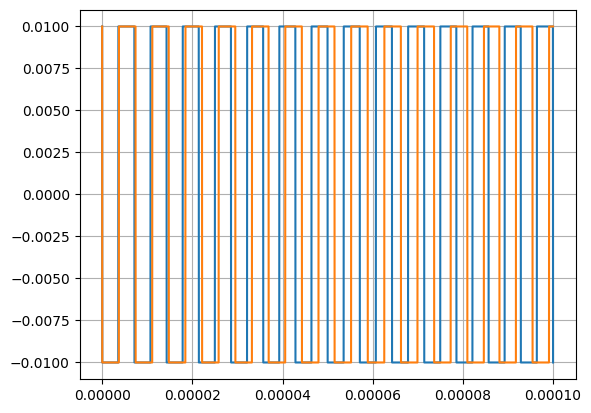

In [25]:
import matplotlib.pyplot as plt
plt.plot(time[:10000], sig[:10000])
plt.plot(time[:10000], sig2[:10000])
plt.grid()

In [26]:
# %pip install emi-receiver

In [27]:
#from emi_receiver import receiver

In [28]:
freqs, peak, avg, qp = emi_receiver_fft(sig/2,1/ts, rbw=9000, band='B')
freqs2, peak2, avg2, qp2= emi_receiver_fft(sig2/2,1/ts, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 24985 samples
  FFT Size      : 40000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 24985 samples
  FFT Size      : 40000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


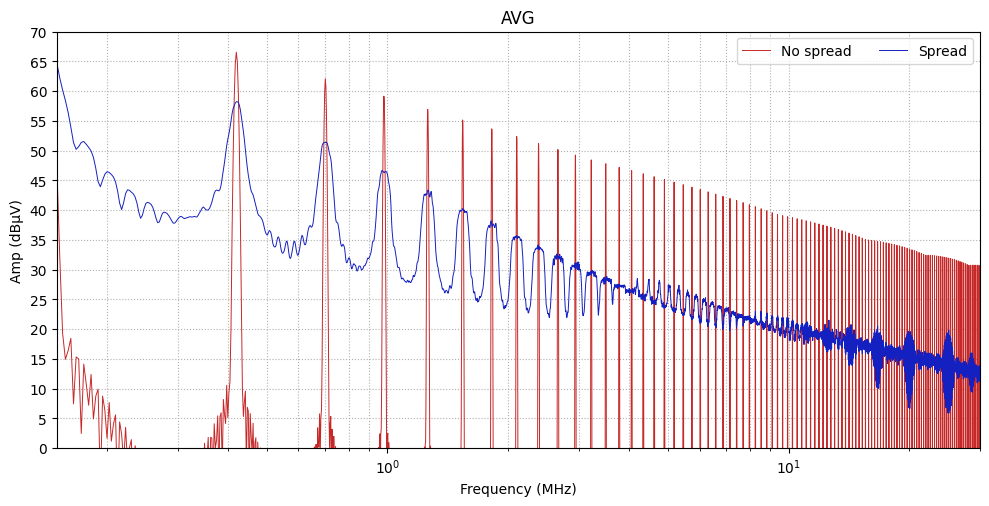

In [29]:


title="AVG"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, avg, label='No spread', color='#C62828', linewidth=0.7)  # slightly lighter red

plt.semilogx(freqs2*1e-6, avg2, label='Spread', color='#1520c0', linewidth=0.7)  # slightly lighter red
#plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")








plt.ylim(0, 70)
plt.yticks(np.arange(0, 71, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.15, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

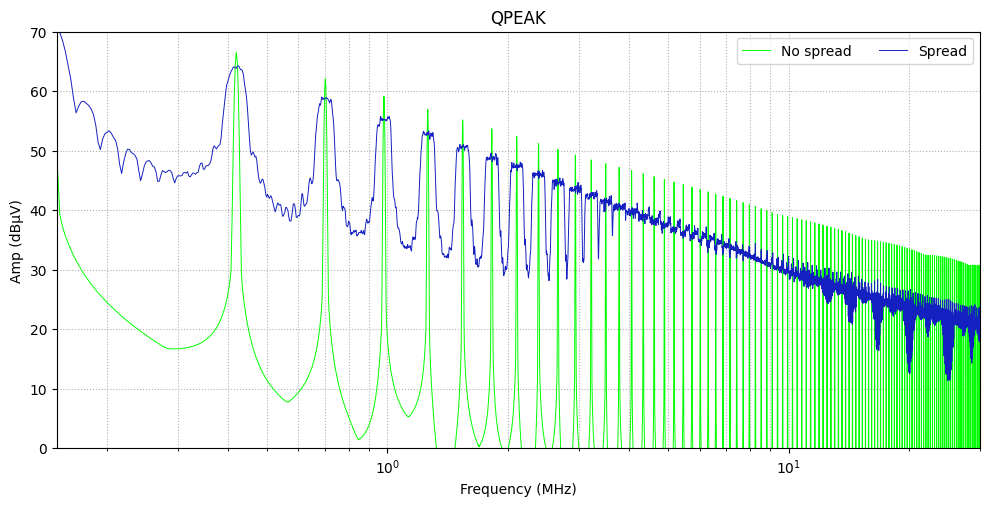

In [30]:


title="QPEAK"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, qp, label='No spread', color='#00FF00', linewidth=0.7)   # slightly lighter red

plt.semilogx(freqs2*1e-6, qp2, label='Spread', color='#1520c0', linewidth=0.7)   # slightly lighter red
#plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")







plt.ylim([0,70])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.15, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

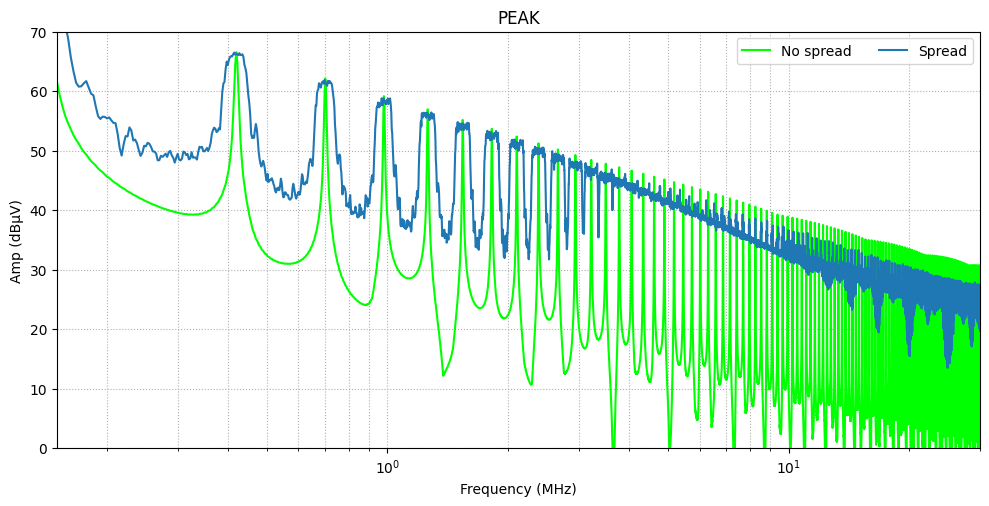

In [31]:


title="PEAK"
plt.figure(figsize=(10,5))
#plt.semilogx(freqs*1e-6, peak, label='Peak', color='k')  # slightly lighter red

plt.semilogx(freqs*1e-6, peak, label='No spread', color='#00FF00')  # slightly lighter red

plt.semilogx(freqs2*1e-6, peak2, label='Spread')  # slightly lighter red
#plt.semilogx(freqs*1e-6, avg,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
#plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
#plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")







plt.ylim([0,70])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.15, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [32]:
import numpy as np
from scipy.signal import butter, lfilter

fs = 100e6          # 100 MHz sampling rate
duration = 0.01     # 10 ms
N = int(fs * duration)

# Target RMS voltage
Vrms = 3.16e-6

# Generate white Gaussian noise
noise = np.random.normal(0, 1, N)

# Bandpass filter: 100 kHz – 30 MHz
low = 100e3 / (fs / 2)
high = 30e6 / (fs / 2)
b, a = butter(4, [low, high], btype='band')
noise = lfilter(b, a, noise)

# Normalize to desired RMS
noise = noise / np.std(noise) * Vrms



freqsn, peakn, avgn, qpn = emi_receiver_fft(noise, fs, rbw=9000, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 24985 samples
  FFT Size      : 40000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


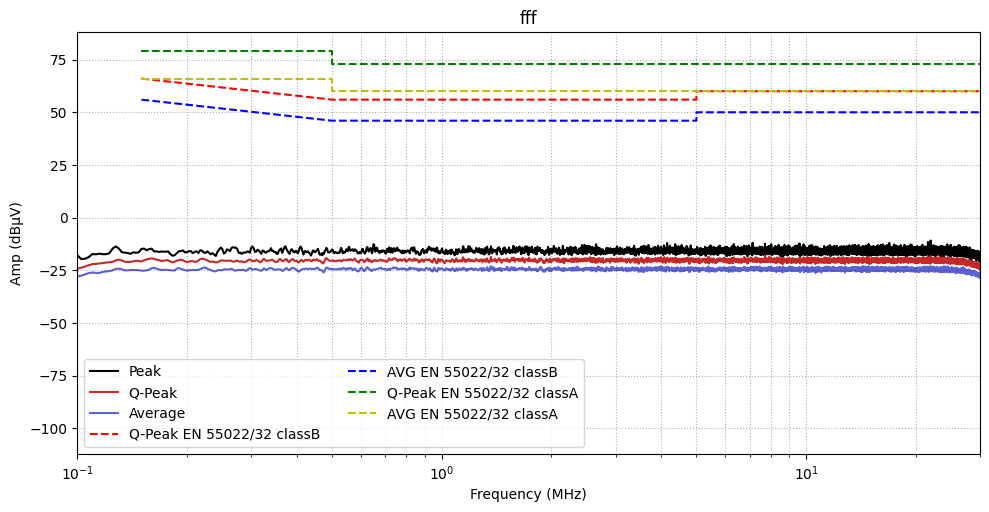

In [33]:


title="fff"
plt.figure(figsize=(10,5))
plt.semilogx(freqsn*1e-6, peakn, label='Peak', color='k')  # slightly lighter red
plt.semilogx(freqsn*1e-6, qpn, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqsn*1e-6, avgn,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")







#plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [34]:
1e-6/ts

100.0

In [35]:
import numpy as np

fs = 100e6
duration = 5e-3
rbw = 9000          # 9 kHz
dbuv_rbw = 15       # what you WANT to see on the plot

N = int(fs * duration)

# total bandwidth (receiver band B ≈ 150 kHz – 30 MHz)
BW_total = 30e6 - 150e3

# dBµV (RBW) -> Vrms in RBW
Vrms_rbw = 1e-6 * 10**(dbuv_rbw / 20)

# convert to TOTAL rms needed
Vrms_total = Vrms_rbw * np.sqrt(BW_total / rbw)

# generate noise
noise = np.random.randn(N)
#noise = noise / np.std(noise) * Vrms_total
noise = noise / np.std(noise) *0.0003
noise = 1e-3*np.random.randn(N)
print("Target Vrms:", Vrms)
print("Measured Vrms:", np.std(noise))


Target Vrms: 3.16e-06
Measured Vrms: 0.0010018780531951558


In [36]:
np.max(noise),np.max( np.random.randn(N))

(np.float64(0.004966161846266803), np.float64(4.695717117883589))

In [37]:
1/ (np.std(noise) * Vrms_total)

np.float64(3082011.2793339225)

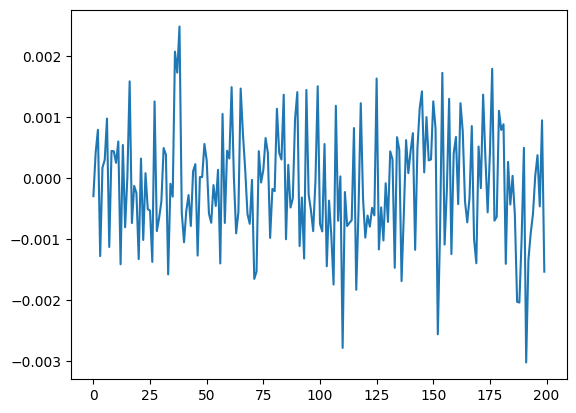

In [38]:
plt.plot(noise[:200])

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 24985 samples
  FFT Size      : 40000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


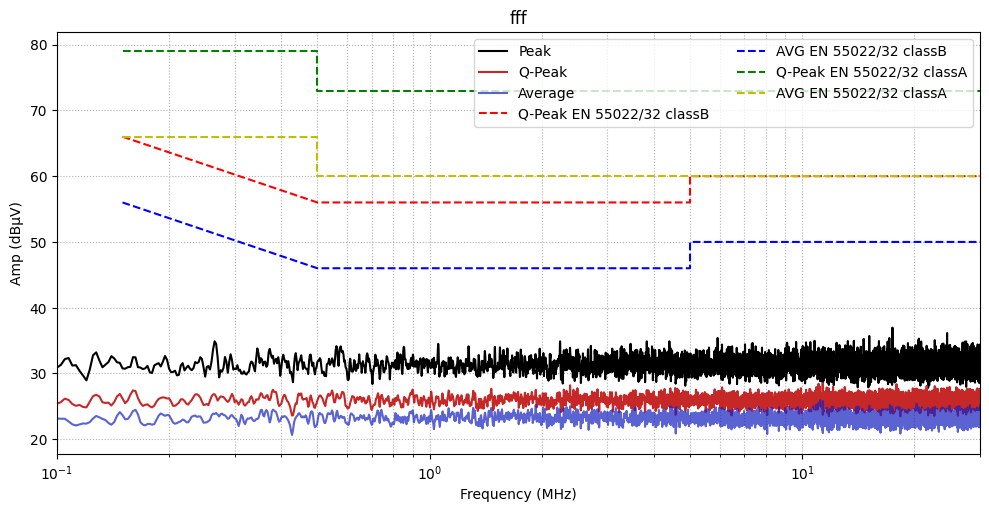

In [39]:
freqsn, peakn, avgn, qpn = emi_receiver_fft(noise, fs, rbw=9000, band='B')





title="fff"
plt.figure(figsize=(10,5))
plt.semilogx(freqsn*1e-6, peakn, label='Peak', color='k')  # slightly lighter red
plt.semilogx(freqsn*1e-6, qpn, label='Q-Peak', color='#C62828')  # slightly lighter red
plt.semilogx(freqsn*1e-6, avgn,   label='Average', color='#1520c0', alpha=0.7)  # slightly lighter blue

# see https://www.ti.com/document-viewer/lit/html/SSZT673
_= """
150 kHz → 530 kHz: 66 dBµV → 56 dBµV (logarithmic slope)
530 kHz → 5 MHz: 56 dBµV (flat)
5 MHz → 30 MHz: 60 dBµV  (flat)
""" # for peak and qpeak is the same , limite are the same for CISPR-16 and 25
# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")







# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="g",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "y",linestyle="--")







#plt.ylim([30,130])
plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Amp (dBµV)')
plt.legend(ncol=2)
plt.tight_layout()
plt.title(title)
plt.show()

In [40]:
len(y), len(noise)

(500000, 500000)

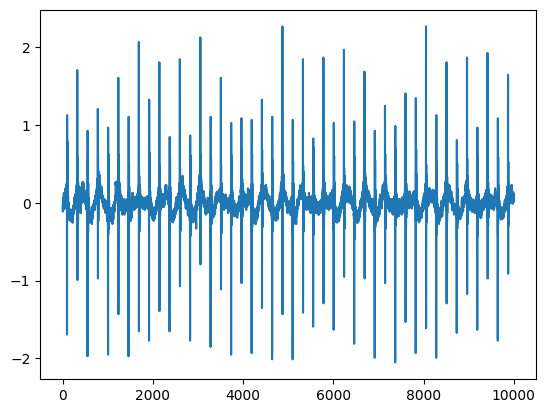

In [41]:
plt.plot(y[:10_000])